
# EDA for ML Forecasting of Land-Animal Populations

**Goals:**
- Explore the data
- Checks whether the dataset is suitable for time-series forecasting
- Creates dataset that can be used for model training


## 1. Import libraries and load the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 120)

candidate_paths = [
    Path("../data/raw/WWF_LPD_2024_public.csv"),
    Path("WWF_LPD_2024_public.csv"),
    Path("/mnt/data/WWF_LPD_2024_public.csv")
]

for dataset_path in candidate_paths:
    if dataset_path.exists():
        break

df = pd.read_csv(dataset_path)
print(f"Loaded dataset from: {dataset_path}")
df.head()

Loaded dataset from: WWF_LPD_2024_public.csv


,ID,Binomial,Replicate,Included in LPR2024,Citation,Class,Order,Family,Genus,Species,Subspecies,Common_name,Location,Country,All_countries,Region,IPBES_region,IPBES_subregion,Latitude,Longitude,Specific_location,System,T_realm,T_biome,FW_realm,FW_biome,M_realm,M_ocean,M_biome,Units,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,Native,Unnamed: 102
0,1,Balearica_regulorum,1,0,"Pomeroy, D. and P. Mwima (2002). The State of ...",Aves,Gruiformes,Gruidae,Balearica,regulorum,NaN,Grey-crowned crane,South-western Uganda,Uganda,Uganda,Africa,Africa,East Africa and adjacent islands,-0.07889,31.13306,0,Terrestrial,Afrotropical,"Tropical and subtropical grasslands, savannas ...",NaN,NaN,NaN,NaN,NaN,Mean number of counts per route,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.5,NaN,NaN,NaN,NaN,NaN,NaN,10.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
1,2,Acrocephalus_sechellensis,1,0,"Rands, M. (1989). ""Saving the Seychelles brush...",Aves,Passeriformes,Acrocephalidae,Acrocephalus,sechellensis,NaN,Seychelles warbler,"Cousin Island, Seychelles",Seychelles,Seychelles,Africa,Africa,East Africa and adjacent islands,-4.33333,55.66667,1,Terrestrial,Afrotropical,Tropical and subtropical moist broadleaf forests,NaN,NaN,NaN,NaN,NaN,Individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,274.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,430.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
2,3,Copsychus_sechellarum,1,0,"Komdeur, J. (1996). ""Breeding of the Seychelle...",Aves,Passeriformes,Muscicapidae,Copsychus,sechellarum,NaN,Seychelles magpie-robin,Seychelles,Seychelles,Seychelles,Africa,Africa,East Africa and adjacent islands,-4.58333,55.66667,0,Terrestrial,Afrotropical,Tropical and subtropical moist broadleaf forests,NaN,NaN,NaN,NaN,NaN,Total population number,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.0,41.0,NaN,NaN,21.0,24.0,NaN,NaN,NaN,NaN,NaN,17.0,NaN,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
3,4,Copsychus_sechellarum,0,1,"Komdeur, J. (1996). ""Breeding of the Seychelle...",Aves,Passeriformes,Muscicapidae,Copsychus,sechellarum,NaN,Seychelles magpie-robin,"Fregate Island, Seychelles",Seychelles,Seychelles,Africa,Africa,East Africa and adjacent islands,-4.58333,55.93333,1,Terrestrial,Afrotropical,Tropical and subtropical moist broadleaf forests,NaN,NaN,NaN,NaN,NaN,Number of individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.0,39.0,38.0,38.0,38.0,24.0,24.0,21.0,25.0,26.0,NaN,23.0,20.0,23.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
4,5,Falco_punctatus,0,1,"Groombridge, J. J., Bruford, M.W., Jones, C.G,...",Aves,Falconiformes,Falconidae,Falco,punctatus,NaN,Mauritius kestrel,"Western Population, Mauritius",Mauritius,Mauritius,Africa,Africa,East Africa and adjacent islands,-20.30000,57.58333,0,Terrestrial,Afrotropical,Tropical and subtropical moist broadleaf forests,NaN,NaN,NaN,NaN,NaN,Number of breeding pairs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,2.0,4.0,1.0,1.0,2.0,2.0,4.0,4.0,7.0,7.0,7.0,9.0,8.0,9.0,13.0,14.0,22.0,26.0,40.0,52.0,58.0,61.0,NaN,NaN,NaN,NaN,NaN

## 2. Overview of the dataset

In [2]:
df.shape

(35996, 103)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35996 entries, 0 to 35995
Columns: 103 entries, ID to Unnamed: 102
dtypes: float64(74), int64(5), object(24)
memory usage: 28.3+ MB


In [4]:
df.columns.tolist()

['ID',
 'Binomial',
 'Replicate',
 'Included in LPR2024',
 'Citation',
 'Class',
 'Order',
 'Family',
 'Genus',
 'Species',
 'Subspecies',
 'Common_name',
 'Location',
 'Country',
 'All_countries',
 'Region',
 'IPBES_region',
 'IPBES_subregion',
 'Latitude',
 'Longitude',
 'Specific_location',
 'System',
 'T_realm',
 'T_biome',
 'FW_realm',
 'FW_biome',
 'M_realm',
 'M_ocean',
 'M_biome',
 'Units',
 '1950',
 '1951',
 '1952',
 '1953',
 '1954',
 '1955',
 '1956',
 '1957',
 '1958',
 '1959',
 '1960',
 '1961',
 '1962',
 '1963',
 '1964',
 '1965',
 '1966',
 '1967',
 '1968',
 '1969',
 '1970',
 '1971',
 '1972',
 '1973',
 '1974',
 '1975',
 '1976',
 '1977',
 '1978',
 '1979',
 '1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '20

**Result summary:**  
The dataset contains a mix of metadata and time-series data.
Time-series data needs to be evaluated for usefullness for time-series-forecasting.
Metadata needs to be evaluated for usefullness as features.

## 3. Separate metadata columns and year columns

In [5]:

year_columns = [col for col in df.columns if str(col).isdigit()]
metadata_columns = [col for col in df.columns if col not in year_columns]

print("Number of year columns:", len(year_columns))
print("First 5 year columns:", year_columns[:5])
print("Last 5 year columns:", year_columns[-5:])
print("Number of metadata columns:", len(metadata_columns))
print("Metadata columns:", metadata_columns)


Number of year columns: 71
First 5 year columns: ['1950', '1951', '1952', '1953', '1954']
Last 5 year columns: ['2016', '2017', '2018', '2019', '2020']
Number of metadata columns: 32
Metadata columns: ['ID', 'Binomial', 'Replicate', 'Included in LPR2024', 'Citation', 'Class', 'Order', 'Family', 'Genus', 'Species', 'Subspecies', 'Common_name', 'Location', 'Country', 'All_countries', 'Region', 'IPBES_region', 'IPBES_subregion', 'Latitude', 'Longitude', 'Specific_location', 'System', 'T_realm', 'T_biome', 'FW_realm', 'FW_biome', 'M_realm', 'M_ocean', 'M_biome', 'Units', 'Native', 'Unnamed: 102']


## 4. Check animal classes and ecosystem types

In [6]:

print("Animal classes:")
print(df["Class"].value_counts())

print("\nEcosystem types:")
print(df["System"].value_counts())


Animal classes:
Class
Aves              17834
Actinopteri       10081
Mammalia           5910
Reptilia            828
Amphibia            699
Elasmobranchii      591
Myxini               28
Holocephali          12
Petromyzonti          9
Dipneusti             3
Coelacanthi           1
Name: count, dtype: int64

Ecosystem types:
System
Marine         16258
Terrestrial    11858
Freshwater      7880
Name: count, dtype: int64


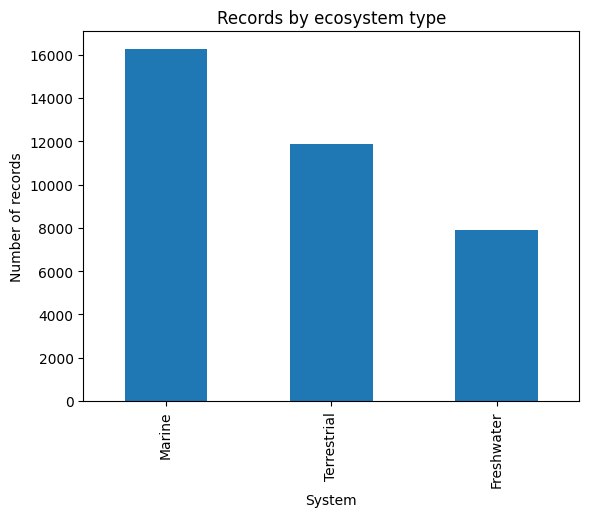

In [7]:

df["System"].value_counts().plot(kind="bar")
plt.title("Records by ecosystem type")
plt.xlabel("System")
plt.ylabel("Number of records")
plt.show()


**Result summary:**  
The dataset contains marine, freshwater, and terrestrial populations. Since the project is about land animals, only terrestrial records need to be kept for the rest of the notebook.


## 5. Filter the dataset to land animals only

In [8]:

land_df = df[df["System"] == "Terrestrial"].copy()

print("Original shape:", df.shape)
print("Land animal shape:", land_df.shape)
print("\nAnimal classes in the land-animal dataset:")
print(land_df["Class"].value_counts())


Original shape: (35996, 103)
Land animal shape: (11858, 103)

Animal classes in the land-animal dataset:
Class
Aves        6134
Mammalia    5137
Reptilia     320
Amphibia     267
Name: count, dtype: int64


## 6. Check missing values in metadata columns

In [9]:
land_df[metadata_columns].isna().sum().sort_values(ascending=False)


M_biome                11858
Unnamed: 102           11858
FW_realm               11858
FW_biome               11858
M_realm                11858
M_ocean                11858
Subspecies             10484
ID                         0
Family                     0
Genus                      0
Replicate                  0
Binomial                   0
Citation                   0
Class                      0
Order                      0
Included in LPR2024        0
Region                     0
All_countries              0
Country                    0
Location                   0
Common_name                0
Species                    0
IPBES_region               0
IPBES_subregion            0
T_biome                    0
T_realm                    0
System                     0
Specific_location          0
Longitude                  0
Latitude                   0
Units                      0
Native                     0
dtype: int64

**Result summary:**  
Columns M_biome, Unnamed: 102, FW_realm, FW_biome, M_realm, and M_ocean are empty entirely.
Column Subspecies is mostly empty.
Due to that, those columns are not needed.
All other metadata columns don't show missing values.

## 7. Keep only useful columns for the forecasting project

In [10]:

columns_to_delete = ["M_biome", "Unnamed: 102", "FW_realm", "FW_biome", "M_realm", "M_ocean", "Subspecies"]

# keep only columns that actually exist in the dataset
metadata_filtered = land_df.copy().drop(columns=columns_to_delete)

print("Project dataset shape:", metadata_filtered.shape)
metadata_filtered.head()


Project dataset shape: (11858, 96)


,ID,Binomial,Replicate,Included in LPR2024,Citation,Class,Order,Family,Genus,Species,Common_name,Location,Country,All_countries,Region,IPBES_region,IPBES_subregion,Latitude,Longitude,Specific_location,System,T_realm,T_biome,Units,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,Native
0,1,Balearica_regulorum,1,0,"Pomeroy, D. and P. Mwima (2002). The State of ...",Aves,Gruiformes,Gruidae,Balearica,regulorum,Grey-crowned crane,South-western Uganda,Uganda,Uganda,Africa,Africa,East Africa and adjacent islands,-0.07889,31.13306,0,Terrestrial,Afrotropical,"Tropical and subtropical grasslands, savannas ...",Mean number of counts per route,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.5,NaN,NaN,NaN,NaN,NaN,NaN,10.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,2,Acrocephalus_sechellensis,1,0,"Rands, M. (1989). ""Saving the Seychelles brush...",Aves,Passeriformes,Acrocephalidae,Acrocephalus,sechellensis,Seychelles warbler,"Cousin Island, Seychelles",Seychelles,Seychelles,Africa,Africa,East Africa and adjacent islands,-4.33333,55.66667,1,Terrestrial,Afrotropical,Tropical and subtropical moist broadleaf forests,Individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,274.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,430.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,3,Copsychus_sechellarum,1,0,"Komdeur, J. (1996). ""Breeding of the Seychelle...",Aves,Passeriformes,Muscicapidae,Copsychus,sechellarum,Seychelles magpie-robin,Seychelles,Seychelles,Seychelles,Africa,Africa,East Africa and adjacent islands,-4.58333,55.66667,0,Terrestrial,Afrotropical,Tropical and subtropical moist broadleaf forests,Total population number,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.0,41.0,NaN,NaN,21.0,24.0,NaN,NaN,NaN,NaN,NaN,17.0,NaN,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,4,Copsychus_sechellarum,0,1,"Komdeur, J. (1996). ""Breeding of the Seychelle...",Aves,Passeriformes,Muscicapidae,Copsychus,sechellarum,Seychelles magpie-robin,"Fregate Island, Seychelles",Seychelles,Seychelles,Africa,Africa,East Africa and adjacent islands,-4.58333,55.93333,1,Terrestrial,Afrotropical,Tropical and subtropical moist broadleaf forests,Number of individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.0,39.0,38.0,38.0,38.0,24.0,24.0,21.0,25.0,26.0,NaN,23.0,20.0,23.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,5,Falco_punctatus,0,1,"Groombridge, J. J., Bruford, M.W., Jones, C.G,...",Aves,Falconiformes,Falconidae,Falco,punctatus,Mauritius kestrel,"Western Population, Mauritius",Mauritius,Mauritius,Africa,Africa,East Africa and adjacent islands,-20.30000,57.58333,0,Terrestrial,Afrotropical,Tropical and subtropical moist broadleaf forests,Number of breeding pairs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,2.0,4.0,1.0,1.0,2.0,2.0,4.0,4.0,7.0,7.0,7.0,9.0,8.0,9.0,13.0,14.0,22.0,26.0,40.0,52.0,58.0,61.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [11]:
metadata_filtered[metadata_filtered["Region"] != metadata_filtered["IPBES_region"]]

,ID,Binomial,Replicate,Included in LPR2024,Citation,Class,Order,Family,Genus,Species,Common_name,Location,Country,All_countries,Region,IPBES_region,IPBES_subregion,Latitude,Longitude,Specific_location,System,T_realm,T_biome,Units,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,Native
180,181,Apteryx_australis,0,1,"De Roy, T. (1999). Queer as a kiwi. BBC Wildl...",Aves,Struthioniformes,Apterygidae,Apteryx,australis,Southern brown kiwi,"Stewart Island, New Zealand",New Zealand,New Zealand,Oceania,Asia and the Pacific,Oceania,-47.00000,168.00000,1,Terrestrial,Australasia,Temperate broadleaf and mixed forests,Individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20000.0,NaN,NaN,NaN,NaN,20000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
181,182,Apteryx_australis,0,1,"De Roy, T. (1999). Queer as a kiwi. BBC Wildl...",Aves,Struthioniformes,Apterygidae,Apteryx,australis,Southern brown kiwi,"Southern South Island, New Zealand",New Zealand,New Zealand,Oceania,Asia and the Pacific,Oceania,-45.33333,167.85000,0,Terrestrial,Australasia,Temperate broadleaf and mixed forests,Individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10000.0,NaN,NaN,NaN,NaN,7400.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
182,183,Apteryx_australis,0,1,"De Roy, T. (1999). Queer as a kiwi. BBC Wildl...",Aves,Struthioniformes,Apterygidae,Apteryx,australis,Southern brown kiwi,"Total Population - North Island, New Zealand",New Zealand,New Zealand,Oceania,Asia and the Pacific,Oceania,-38.68333,176.08333,0,Terrestrial,Australasia,Temperate broadleaf and mixed forests,Individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51000.0,NaN,NaN,NaN,NaN,38000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
183,184,Apteryx_haastii,0,1,"De Roy, T. (1999). Queer as a kiwi. BBC Wildli...",Aves,Struthioniformes,Apterygidae,Apteryx,haastii,Great spotted kiwi,"North west of South Island, New Zealand",New Zealand,New Zealand,Oceania,Asia and the Pacific,Oceania,-41.33333,172.33333,0,Terrestrial,Australasia,Temperate broadleaf and mixed forests,Individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15000.0,NaN,NaN,NaN,NaN,11100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
184,185,Apteryx_owenii,0,1,"De Roy, T. (1999). Queer as a kiwi. BBC Wildl...",Aves,Struthioniformes,Apterygidae,Apteryx,owenii,Little spotted kiwi,Total - isolated to NZ off shore islands (used...,New Zealand,New Zealand,Oceania,Asia and the Pacific,Oceania,-40.86667,174.90000,0,Terrestrial,Australasia,Temperate broadleaf and mixed forests,Individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1065.0,NaN,NaN,NaN,NaN,1105.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

With empty columns filtered out, there's still metadata that is not needed for further analysis for this project:
- ID: redundant because of the index
- Replicate
- Included in LPR2024
- Citation
- Country: Redundant because it is included in All_countries
- Region and IPBES_region: One region-column is sufficient and IPBES_subregion seems to be descriptive enough.
- Specific_location
- System: Redundant since data is reduced to one system


In [12]:
# Drop irrelevant columns
irrelevant_columns = ["ID", "Replicate", "Included in LPR2024", "Citation", "Country", "Region", "IPBES_region", "Specific_location", "System"]
metadata_filtered = metadata_filtered.drop(columns=irrelevant_columns)


## 13. Explore the Units column

The `Units` column describes how population values were measured.  
This is important because not all time series are directly comparable. Some entries are raw counts, some are indices, and others are rates or densities.


In [13]:

units_counts = metadata_filtered["Units"].value_counts(dropna=False)

print("Number of unique unit labels:", metadata_filtered["Units"].nunique())
units_counts.head(20)


Number of unique unit labels: 1039


Units
Sample: abundance (counts)                                                                 1934
Number of individuals                                                                       993
Annual Index                                                                                906
Annual index of population change                                                           539
Individuals                                                                                 485
Sample: density (counts/fixed areas)                                                        371
Index                                                                                       288
Population estimate (individuals)                                                           235
Encounter rate (birds 100 km-1)                                                             180
Estimated number of individuals                                                             175
Number of breeding pairs          

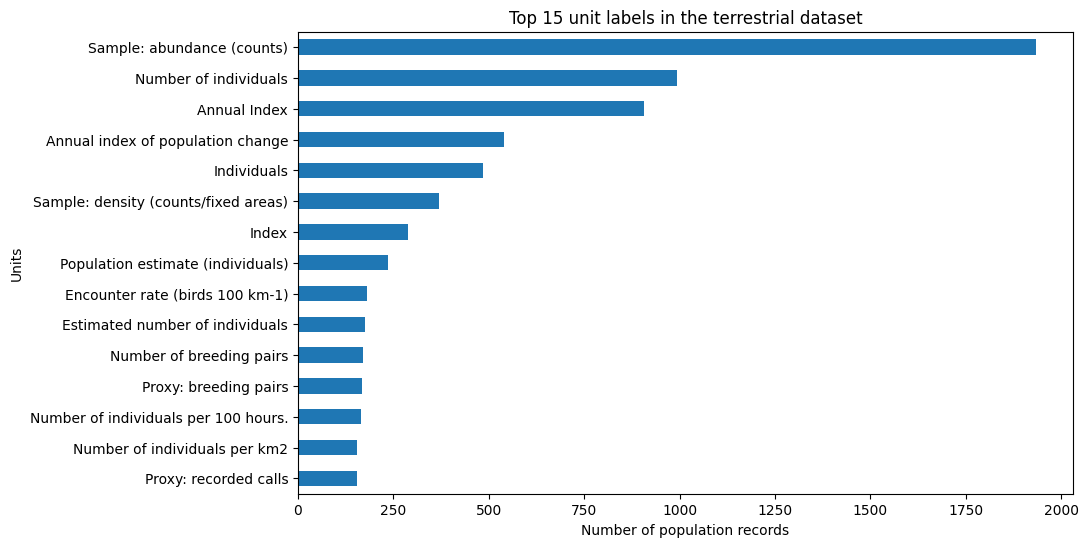

In [14]:

units_counts.head(15).sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Top 15 unit labels in the terrestrial dataset")
plt.xlabel("Number of population records")
plt.ylabel("Units")
plt.show()


In [15]:

def classify_unit(unit):
    unit_lower = str(unit).lower()

    if "index" in unit_lower:
        return "Index"
    elif "density" in unit_lower or "/km2" in unit_lower or "per km2" in unit_lower:
        return "Density"
    elif "rate" in unit_lower or "per 100" in unit_lower or "trap nights" in unit_lower or "encounter" in unit_lower:
        return "Rate / effort-based"
    elif "pair" in unit_lower:
        return "Breeding pairs"
    elif "individual" in unit_lower or "abundance" in unit_lower or "counts" in unit_lower:
        return "Counts / individuals"
    else:
        return "Other"

metadata_filtered["Unit_group"] = metadata_filtered["Units"].apply(classify_unit)
metadata_filtered["Unit_group"].value_counts()


Unit_group
Counts / individuals    5258
Index                   2305
Other                   1694
Rate / effort-based     1028
Density                  944
Breeding pairs           629
Name: count, dtype: int64

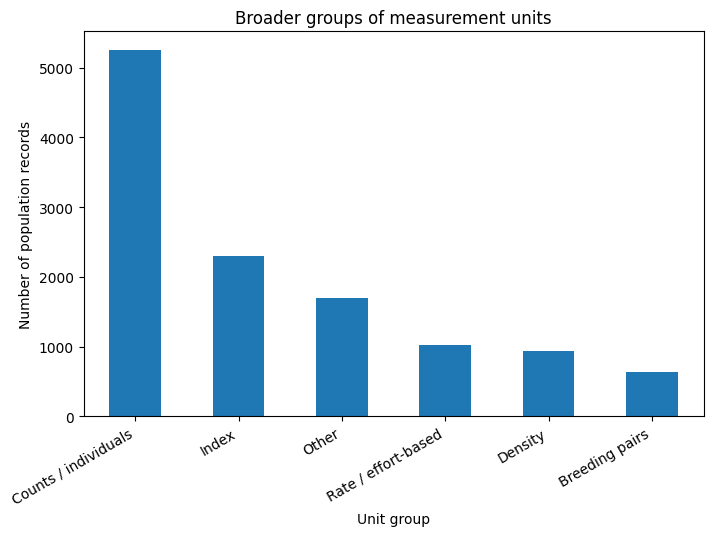

In [16]:

metadata_filtered["Unit_group"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("Broader groups of measurement units")
plt.xlabel("Unit group")
plt.ylabel("Number of population records")
plt.xticks(rotation=30, ha="right")
plt.show()



**Result summary:**  
The `Units` column contains many different labels, which shows that the dataset combines several measurement approaches.  
Many records are based on counts or individuals, but index-based and effort-based measures are also common. This means the population values are not always directly comparable across species and studies. For later modeling, this column should either be used as a feature or the data should be restricted to a smaller set of compatible unit types.



## 14. Analyze gaps in the time-series data

Missing values inside a time series can be important for forecasting.  
A gap can mean different things:

- no observation was made in that year
- the survey was not possible or not recorded
- the data source only reported some years
- in rare cases, a species may have disappeared locally

Because the dataset does not explicitly encode the reason for every missing value, missing values should be treated as **unknown** and not automatically as zero or extinction.


In [17]:
gap_base = metadata_filtered.copy()
gap_base["population_row"] = gap_base.index

def summarize_time_series(row):
    observed_years = [int(year) for year in year_columns if pd.notna(row[year])]

    if len(observed_years) == 0:
        return pd.Series({
            "first_year": np.nan,
            "last_year": np.nan,
            "observations": 0,
            "span_years": 0,
            "internal_gap_years": np.nan,
            "gap_ratio": np.nan
        })

    first_year = min(observed_years)
    last_year = max(observed_years)
    observations = len(observed_years)
    span_years = last_year - first_year + 1
    internal_gap_years = span_years - observations
    gap_ratio = internal_gap_years / span_years

    return pd.Series({
        "first_year": first_year,
        "last_year": last_year,
        "observations": observations,
        "span_years": span_years,
        "internal_gap_years": internal_gap_years,
        "gap_ratio": gap_ratio
    })

gap_summary = gap_base.apply(summarize_time_series, axis=1)

geo_col = "All_countries" if "All_countries" in gap_base.columns else "Country"

gap_df = pd.concat(
    [
        gap_base[["population_row", "Common_name", "Location", geo_col,
                  "IPBES_subregion", "Latitude", "Longitude", "Units", "Unit_group"]],
        gap_summary
    ],
    axis=1
)

gap_df.head()

,population_row,Common_name,Location,All_countries,IPBES_subregion,Latitude,Longitude,Units,Unit_group,first_year,last_year,observations,span_years,internal_gap_years,gap_ratio
0,0,Grey-crowned crane,South-western Uganda,Uganda,East Africa and adjacent islands,-0.07889,31.13306,Mean number of counts per route,Counts / individuals,1985.0,2002.0,3.0,18.0,15.0,0.833333
1,1,Seychelles warbler,"Cousin Island, Seychelles",Seychelles,East Africa and adjacent islands,-4.33333,55.66667,Individuals,Counts / individuals,1958.0,1987.0,3.0,30.0,27.0,0.900000
2,2,Seychelles magpie-robin,Seychelles,Seychelles,East Africa and adjacent islands,-4.58333,55.66667,Total population number,Other,1977.0,1990.0,6.0,14.0,8.0,0.571429
3,3,Seychelles magpie-robin,"Fregate Island, Seychelles",Seychelles,East Africa and adjacent islands,-4.58333,55.93333,Number of individuals,Counts / individuals,1976.0,1990.0,14.0,15.0,1.0,0.066667
4,4,Mauritius kestrel,"Western Population, Mauritius",Mauritius,East Africa and adjacent islands,-20.30000,57.58333,Number of breeding pairs,Breeding pairs,1973.0,1997.0,25.0,25.0,0.0,0.000000


In [18]:

gap_df[["observations", "span_years", "internal_gap_years", "gap_ratio"]].describe()


,observations,span_years,internal_gap_years,gap_ratio
count,11858.000000,11858.000000,11853.000000,11853.000000
mean,12.809411,17.284702,4.477179,0.251241
std,14.105535,14.010776,8.104485,0.333217
min,0.000000,0.000000,0.000000,0.000000
25%,3.000000,5.000000,0.000000,0.000000
50%,6.000000,13.000000,0.000000,0.000000
75%,18.000000,26.000000,5.000000,0.529412
max,63.000000,71.000000,53.000000,0.960000


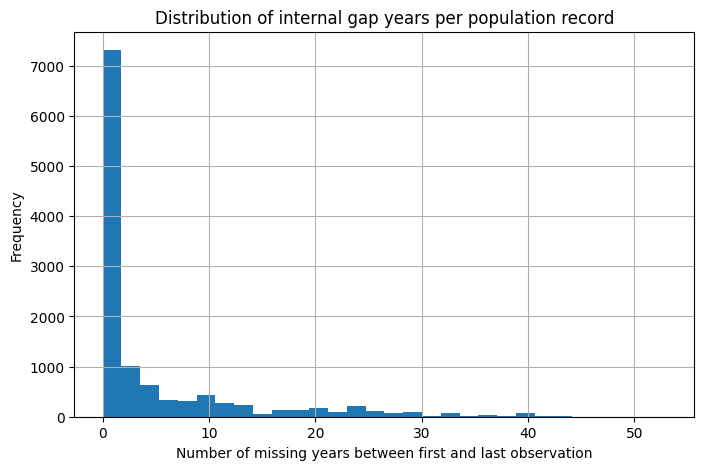

In [19]:

gap_df["internal_gap_years"].dropna().hist(bins=30, figsize=(8,5))
plt.title("Distribution of internal gap years per population record")
plt.xlabel("Number of missing years between first and last observation")
plt.ylabel("Frequency")
plt.show()


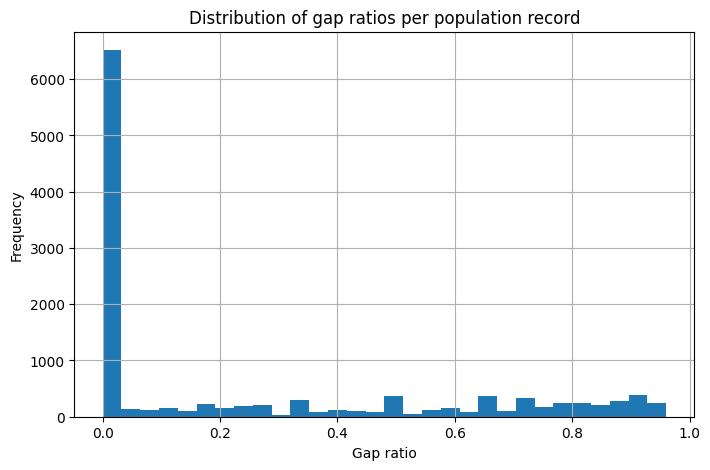

In [20]:

gap_df["gap_ratio"].dropna().hist(bins=30, figsize=(8,5))
plt.title("Distribution of gap ratios per population record")
plt.xlabel("Gap ratio")
plt.ylabel("Frequency")
plt.show()



**Result summary:**  
Many population records are not fully continuous. Some have only a few internal gaps, while others are much more fragmented.  
For forecasting, this matters because models learn best from consistent time series. Records with many missing years may require imputation, careful filtering, or a different modeling approach.



## 15. Inspect examples of highly fragmented time series

Looking at a few concrete examples makes the gaps easier to understand.


In [21]:
geo_col = "All_countries" if "All_countries" in gap_df.columns else "Country"

gap_df.sort_values(["internal_gap_years", "gap_ratio"], ascending=False)[
    ["Common_name", geo_col, "Location", "first_year", "last_year",
     "observations", "span_years", "internal_gap_years", "gap_ratio", "Units"]
].head(15)

,Common_name,All_countries,Location,first_year,last_year,observations,span_years,internal_gap_years,gap_ratio,Units
35993,European bison,"Belarus, Poland, Russian Federation, Ukraine, ...",Europe,1950.0,2020.0,18.0,71.0,53.0,0.746479,Number of individuals
19673,Greater one-horned rhino,Nepal,"Nepal (Chitwan NP, Bardia NP and Suklaphanta W...",1950.0,2015.0,14.0,66.0,52.0,0.787879,Number of individuals
14720,Greater one-horned rhino,Nepal,Chitwan National Park,1950.0,2011.0,13.0,62.0,49.0,0.790323,Number of individuals
23109,Greater Glider (southern and central),Australia,Highlands-Northern Fall,1968.0,2017.0,2.0,50.0,48.0,0.960000,Sample: abundance (counts)
9824,Grizzly bear / Brown bear,Slovakia,"Western Carpathian Mountains, Slovakia",1952.0,2005.0,7.0,54.0,47.0,0.870370,Estimated population size (number of individuals)
21671,European badger,Belarus,Belarussian part of BiaÅ‚owieÅ¼a Primeval Forest,1951.0,1999.0,3.0,49.0,46.0,0.938776,Estimated number of individuals / 10km2
9847,White-tailed sea-eagle,Serbia,Serbia,1950.0,2009.0,14.0,60.0,46.0,0.766667,Number of breeding pairs
2917,American bison / Wood bison / Plains bison,Canada,Mackenzie Bison Sanctuary,1957.0,2004.0,3.0,48.0,45.0,0.937500,Individuals
9833,White-tailed sea-eagle,Ukraine,Ukraine,1950.0,2000.0,6.0,51.0,45.0,0.882353,Number of pairs
498,European bison,Poland,"Bialowieza National Park, Poland",1952.0,2000.0,5.0,49.0,44.0,0.897959,Number of individuals


In [22]:
geo_col = "All_countries" if "All_countries" in gap_df.columns else "Country"

example_species = gap_df.sort_values("internal_gap_years", ascending=False).iloc[0]["Common_name"]
example_area = gap_df.sort_values("internal_gap_years", ascending=False).iloc[0][geo_col]

example_rows = metadata_filtered[
    (metadata_filtered["Common_name"] == example_species) &
    (metadata_filtered[geo_col] == example_area)
]

example_rows[["Common_name", geo_col] + year_columns].head(1)

,Common_name,All_countries,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
35993,European bison,"Belarus, Poland, Russian Federation, Ukraine, ...",0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,52.0,NaN,NaN,NaN,NaN,239.0,NaN,NaN,NaN,NaN,499.0,NaN,NaN,NaN,NaN,749.0,NaN,NaN,NaN,NaN,988.0,NaN,NaN,NaN,NaN,1383.0,NaN,NaN,NaN,NaN,1851.0,NaN,NaN,NaN,NaN,1872.0,NaN,NaN,NaN,NaN,1716.0,NaN,NaN,NaN,NaN,2132.0,NaN,NaN,NaN,NaN,2756.0,NaN,NaN,NaN,NaN,3994.0,NaN,5024.0,5357.0,6244.0,6819.0



**Result summary:**  
The examples show that some time series cover a long period but include many missing years inside that period.  
These gaps should not be interpreted automatically as population collapse or extinction. In this dataset, missing values more safely mean that no population value is available for that year. The reason could be missing surveys, missing reporting, methodological changes, or a real disappearance that was not coded separately.
In cases like these, the question needs to be answered if there is enough recent data to work with.



## 16. Explore the geographical distribution of observations

Before choosing an MVP location, it helps to see where most population records are concentrated.


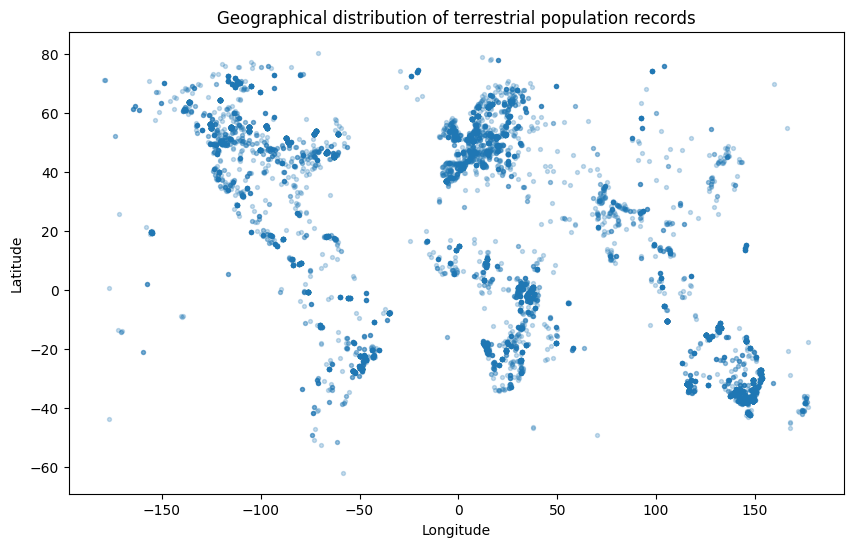

In [23]:

plt.figure(figsize=(10,6))
plt.scatter(
    gap_df["Longitude"],
    gap_df["Latitude"],
    s=8,
    alpha=0.25
)
plt.title("Geographical distribution of terrestrial population records")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [24]:
geo_col = "All_countries" if "All_countries" in gap_df.columns else "Country"

country_record_counts = gap_df.groupby(geo_col).size().sort_values(ascending=False)
country_record_counts.head(20)

All_countries
Australia                       3218
Canada                          2241
Brazil                           837
United States                    531
Spain                            340
Namibia                          252
Kenya                            190
Norway                           186
United Kingdom                   185
Tanzania, United Republic Of     171
Sweden                           163
Uganda                           158
Russian Federation               146
South Africa                     137
France                           137
India                            130
Cameroon                         130
Finland                          124
Poland                           120
Mexico                           102
dtype: int64

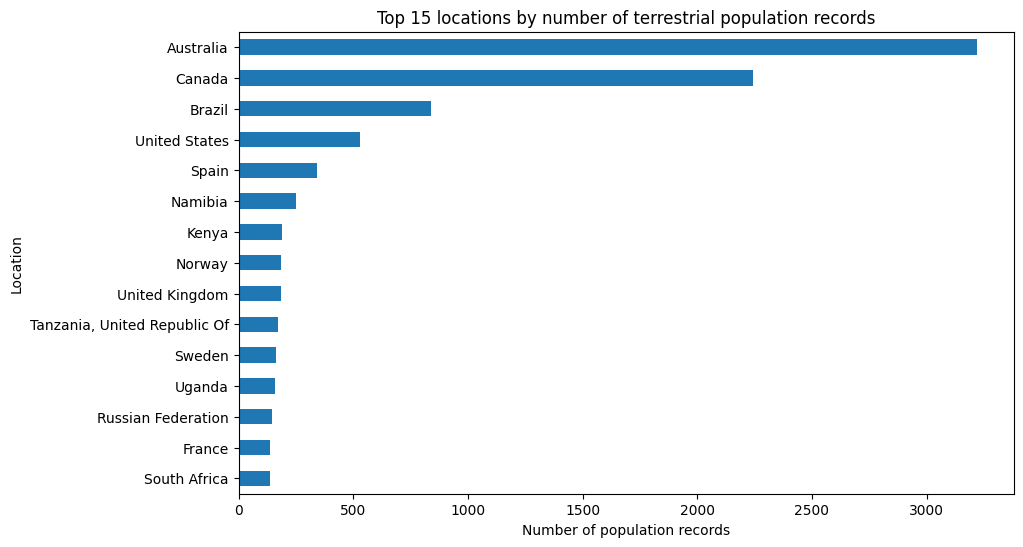

In [25]:
country_record_counts.head(15).sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Top 15 locations by number of terrestrial population records")
plt.xlabel("Number of population records")
plt.ylabel("Location")
plt.show()


**Result summary:**  
The observations are not evenly distributed across the world. Some locations and regions contribute many more population records than others.  
This matters for project scoping: choosing an MVP location with many records makes it easier to merge climate data, train a first model, and create a more reliable dashboard.



## 17. Check whether gaps differ by location

The next question is whether some locations have more fragmented time series than others.


In [26]:
geo_col = "All_countries" if "All_countries" in gap_df.columns else "Country"

country_gap_summary = (
    gap_df.groupby(geo_col)
    .agg(
        population_records=("population_row", "count"),
        mean_observations=("observations", "mean"),
        mean_span_years=("span_years", "mean"),
        mean_internal_gap_years=("internal_gap_years", "mean"),
        mean_gap_ratio=("gap_ratio", "mean")
    )
    .sort_values("population_records", ascending=False)
)

country_gap_summary.head(10)

,population_records,mean_observations,mean_span_years,mean_internal_gap_years,mean_gap_ratio
All_countries,,,,,
Australia,3218,6.713176,10.144500,3.431324,0.253348
Canada,2241,30.565819,32.057117,1.494633,0.104360
Brazil,837,2.634409,7.495818,4.861410,0.327157
United States,531,10.359699,15.883239,5.523540,0.246746
Spain,340,13.550000,17.276471,3.726471,0.139713
Namibia,252,10.976190,12.698413,1.722222,0.139126
Kenya,190,5.852632,20.484211,14.631579,0.606747
Norway,186,12.908602,15.155914,2.247312,0.087251
United Kingdom,185,18.502703,21.335135,2.832432,0.134331


In [27]:

countries_with_enough_records = country_gap_summary[country_gap_summary["population_records"] >= 20]

countries_with_enough_records.sort_values("mean_gap_ratio", ascending=False).head(15)


,population_records,mean_observations,mean_span_years,mean_internal_gap_years,mean_gap_ratio
All_countries,,,,,
"Burkina Faso, Niger, Mali",56,2.000000,34.000000,32.000000,0.941176
Mozambique,29,4.000000,31.344828,27.344828,0.832647
Cameroon,130,2.984615,23.853846,20.869231,0.813406
Northern Mariana Islands,20,3.000000,18.700000,15.700000,0.793830
Botswana,99,2.222222,20.050505,17.828283,0.769842
Central African Republic,20,3.400000,15.450000,12.050000,0.714080
Uganda,158,4.620253,22.867089,18.246835,0.710980
Ghana,21,5.904762,17.476190,11.571429,0.606880
Kenya,190,5.852632,20.484211,14.631579,0.606747


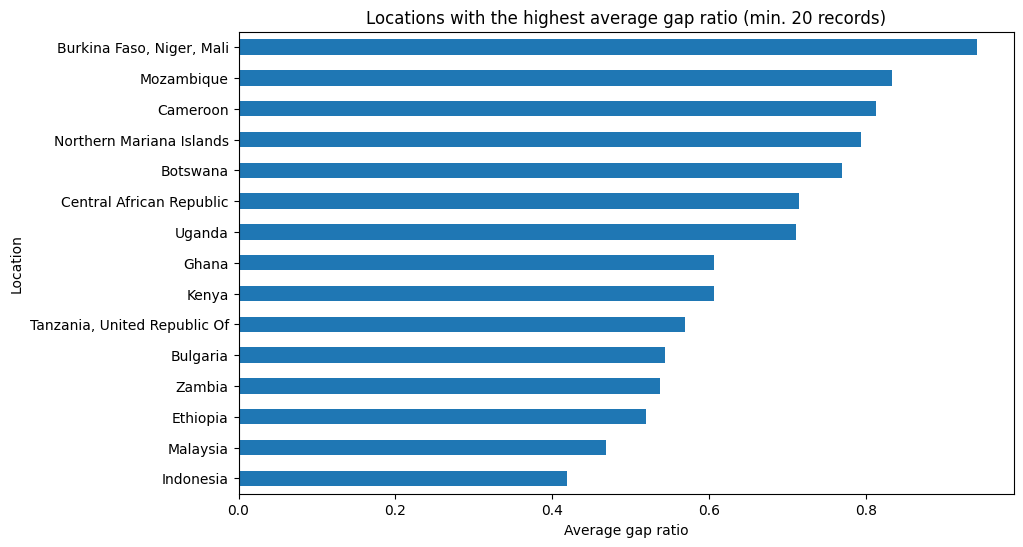

In [28]:
countries_with_enough_records.sort_values("mean_gap_ratio", ascending=False).head(15)[
    "mean_gap_ratio"
].sort_values().plot(kind="barh", figsize=(10,6))

plt.title("Locations with the highest average gap ratio (min. 20 records)")
plt.xlabel("Average gap ratio")
plt.ylabel("Location")
plt.show()

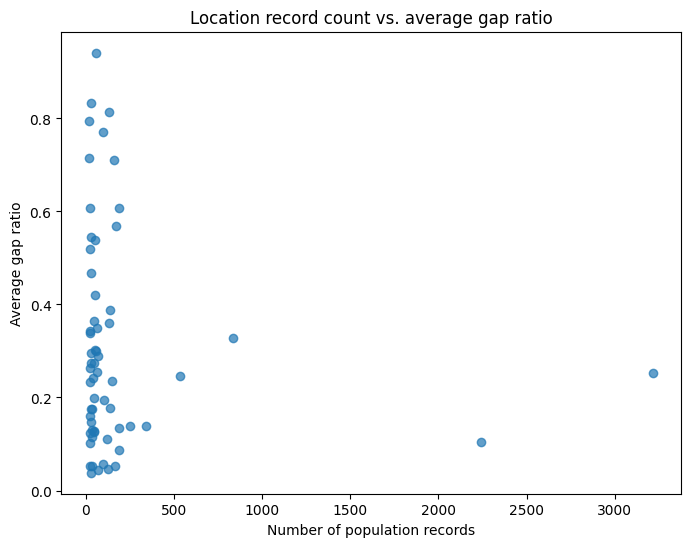

,population_records,mean_gap_ratio
population_records,1.000000,-0.099716
mean_gap_ratio,-0.099716,1.000000


In [29]:
plt.figure(figsize=(8,6))
plt.scatter(
    countries_with_enough_records["population_records"],
    countries_with_enough_records["mean_gap_ratio"],
    alpha=0.7
)
plt.title("Location record count vs. average gap ratio")
plt.xlabel("Number of population records")
plt.ylabel("Average gap ratio")
plt.show()

countries_with_enough_records[["population_records", "mean_gap_ratio"]].corr()


**Result summary:**  
The level of fragmentation differs between locations. Some locations have many records and relatively continuous time series, while others have fewer records and larger average gaps.  
For an MVP, it could be useful to focus on locations that combine **enough observations** with **lower gap ratios**, because that reduces preprocessing effort and makes the first forecasting model more robust.


# **Final insight**

The extended EDA shows that the dataset is useful for forecasting land-animal populations, but it also reveals important challenges:

- the `Units` column is heterogeneous, so population values are not always directly comparable
- many time series contain internal gaps
- missing values do **not** automatically mean extinction; they mainly mean that no value is available
- geographical coverage is uneven
- some countries combine richer data coverage with fewer gaps, making them stronger candidates for an MVP
